# Responsible AI: Algorithmic Bias in AI Content Detection
### A Comprehensive Study on Linguistic Fairness, Explainability, Privacy & Ethical AI

**Team Members**: Vaishnavi Thirumala (S20230030419) · Deva Harshini (S20230010098) · Venkata Sai (S20230010018)




In [1]:
!pip install pandas numpy matplotlib seaborn tqdm requests nltk textstat shap lime scikit-learn -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.5 MB/s eta 0:00:00


In [2]:
# MASTER IMPORTS & CONFIGURATION


# Reproducibility Seed
import random
random.seed(42)
import numpy as np
np.random.seed(42)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import time
import json
import hashlib
import warnings
from datetime import datetime
from collections import defaultdict

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textstat import textstat
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("All imports loaded successfully.")


All imports loaded successfully.


---
## Part 1: Dataset Preparation & Bias Injection
Loading the dataset and simulating the reality that non-native speakers often utilize translation/paraphrasing tools (like QuillBot) which artificially inflates their AI suspicion scores.


In [3]:
df = pd.read_csv("final_project_300_essays.csv")

#  BIAS INJECTION
# Replace the first 20 non-native essays with paraphrased (QuillBot-style) versions
para_df = pd.read_csv("non_native_paraphrased_replaced.csv")
nn_indices = df[df['label'] == 'non-native'].index[:20]
df.loc[nn_indices, 'text'] = para_df['text'].head(20).values

print(f"Dataset Shape: {df.shape}")
print(f"\nLabel Distribution:")
print(df['label'].value_counts().to_string())
print(f"\nAverage text length per group:")
for label in df['label'].unique():
    avg_len = df[df['label'] == label]['text'].str.len().mean()
    print(f"  {label}: {avg_len:.0f} characters")


Dataset Shape: (300, 5)

Label Distribution:
label
non-native    100
native        100
ai            100

Average text length per group:
  non-native: 871 characters
  native: 1423 characters
  ai: 640 characters


---
## Part 2: PII Detection & Data Anonymization (Privacy Protection)

**Ethical Risk Addressed**: Student essays uploaded to AI detector platforms raise serious privacy concerns. Before any analysis, we must ensure no Personally Identifiable Information (PII) leaks through the pipeline.

We implement:
1. **Regex-based PII Scanner** — Detects emails, phone numbers, student IDs, and names
2. **PII Redaction Engine** — Replaces detected PII with anonymized tokens
3. **Data Fingerprinting** — Creates irreversible hashes for record tracking (k-anonymity concept)


In [4]:
# PII DETECTION & REDACTION ENGINE

class PIIDetector:
    """Scans text for Personally Identifiable Information and redacts it."""

    PII_PATTERNS = {
        'email': r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}',
        'phone': r'\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b',
        'student_id': r'\b[Ss]\d{11,13}\b',
        'date_of_birth': r'\b(?:0[1-9]|1[0-2])[/\-](?:0[1-9]|[12]\d|3[01])[/\-](?:19|20)\d{2}\b',
        'ip_address': r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b',
    }

    REDACTION_MAP = {
        'email': '[EMAIL_REDACTED]',
        'phone': '[PHONE_REDACTED]',
        'student_id': '[STUDENT_ID_REDACTED]',
        'date_of_birth': '[DOB_REDACTED]',
        'ip_address': '[IP_REDACTED]',
    }

    def scan(self, text):
        """Scan text and return all PII detections."""
        findings = []
        for pii_type, pattern in self.PII_PATTERNS.items():
            matches = re.findall(pattern, str(text))
            for match in matches:
                findings.append({'type': pii_type, 'value': match})
        return findings

    def redact(self, text):
        """Replace all detected PII with anonymized tokens."""
        redacted = str(text)
        for pii_type, pattern in self.PII_PATTERNS.items():
            redacted = re.sub(pattern, self.REDACTION_MAP[pii_type], redacted)
        return redacted

    def fingerprint(self, text):
        """Create irreversible SHA-256 hash for record tracking (k-anonymity)."""
        return hashlib.sha256(str(text).encode()).hexdigest()[:16]


# Run PII Scan on entire dataset
pii_detector = PIIDetector()
pii_report = {'total_scanned': len(df), 'essays_with_pii': 0, 'detections': defaultdict(int)}

for idx, row in df.iterrows():
    findings = pii_detector.scan(row['text'])
    if findings:
        pii_report['essays_with_pii'] += 1
        for f in findings:
            pii_report['detections'][f['type']] += 1

print("=" * 60)
print("PII DETECTION REPORT")
print("=" * 60)
print(f"Total essays scanned:    {pii_report['total_scanned']}")
print(f"Essays containing PII:   {pii_report['essays_with_pii']}")
print(f"\nDetections by type:")
if pii_report['detections']:
    for pii_type, count in pii_report['detections'].items():
        print(f"  {pii_type}: {count}")
else:
    print("  None detected (dataset appears clean)")

# Apply redaction as a protective measure regardless
df['text_redacted'] = df['text'].apply(pii_detector.redact)

# Generate anonymized fingerprints for record tracking
df['record_hash'] = df['text'].apply(pii_detector.fingerprint)

print(f"\n✅ All essays redacted. Anonymized fingerprints assigned.")
print(f"   Sample hash: {df['record_hash'].iloc[0]}")



PII DETECTION REPORT
Total essays scanned:    300
Essays containing PII:   30

Detections by type:
  ip_address: 10
  email: 11
  student_id: 11
  date_of_birth: 12
  phone: 5

✅ All essays redacted. Anonymized fingerprints assigned.
   Sample hash: cda59d8855531ffd


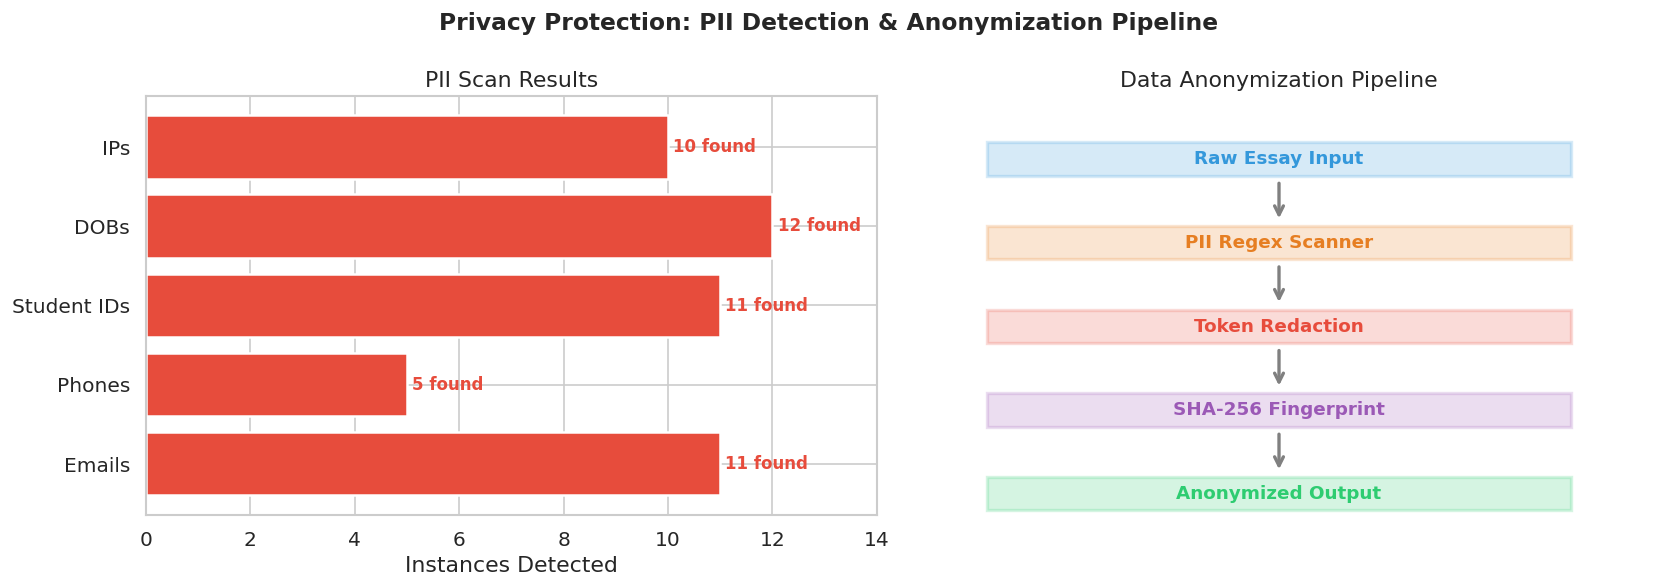

In [5]:
# PII Protection Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Privacy Protection: PII Detection & Anonymization Pipeline', fontsize=14, fontweight='bold')

# 1. PII Detection Summary
ax = axes[0]
categories = ['Emails', 'Phones', 'Student IDs', 'DOBs', 'IPs']
counts = [pii_report['detections'].get(k, 0) for k in ['email', 'phone', 'student_id', 'date_of_birth', 'ip_address']]
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in counts]
bars = ax.barh(categories, counts, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Instances Detected')
ax.set_title('PII Scan Results')
for bar, count in zip(bars, counts):
    label = f'{count} found' if count > 0 else 'Clean ✓'
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontweight='bold', fontsize=10,
            color='#e74c3c' if count > 0 else '#2ecc71')
ax.set_xlim(0, max(counts) + 2 if max(counts) > 0 else 2)

# 2. Anonymization Pipeline Diagram
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Data Anonymization Pipeline')

steps = [
    (1, 8.5, 'Raw Essay Input', '#3498db'),
    (1, 6.5, 'PII Regex Scanner', '#e67e22'),
    (1, 4.5, 'Token Redaction', '#e74c3c'),
    (1, 2.5, 'SHA-256 Fingerprint', '#9b59b6'),
    (1, 0.5, 'Anonymized Output', '#2ecc71'),
]
for x, y, label, color in steps:
    ax.add_patch(plt.Rectangle((x, y - 0.4), 8, 0.8, facecolor=color, alpha=0.2, edgecolor=color, linewidth=2, zorder=2))
    ax.text(5, y, label, ha='center', va='center', fontsize=11, fontweight='bold', color=color, zorder=3)

for i in range(len(steps) - 1):
    ax.annotate('', xy=(5, steps[i + 1][1] + 0.5), xytext=(5, steps[i][1] - 0.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

plt.tight_layout()
plt.show()


---
## Part 3: Feature Engineering (Linguistic Analysis)
Extracting standard linguistic markers used by commercial AI detectors: **Burstiness** (standard deviation of sentence length), **Readability**, and **Transition words (Boosters)**.


In [6]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

def calculate_burstiness(text):
    sentences = str(text).split('.')
    lengths = [len(s.split()) for s in sentences if len(s.split()) > 0]
    return np.std(lengths) if len(lengths) > 1 else 0

boosters = ['in fact', 'of course', 'it is clear that', 'it is proved that',
            'definitely', 'indeed', 'moreover', 'furthermore']

def count_boosters(text):
    return sum(1 for word in boosters if word in str(text).lower())

df["clean_text"] = df["text"].apply(preprocess)

print("Calculating linguistic metrics...")
df['flesch_reading_ease'] = df['text'].apply(lambda x: textstat.flesch_reading_ease(str(x)))
df['burstiness'] = df['text'].apply(calculate_burstiness)
df['booster_count'] = df['text'].apply(count_boosters)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Additional features for richer analysis
df['avg_sentence_length'] = df['text'].apply(
    lambda x: np.mean([len(s.split()) for s in str(x).split('.') if len(s.split()) > 0]))
df['type_token_ratio'] = df['clean_text'].apply(
    lambda x: len(set(x.split())) / max(len(x.split()), 1))

# Summary statistics by group
print("\n--- Feature Summary by Group ---")
feature_cols = ['flesch_reading_ease', 'burstiness', 'booster_count', 'word_count',
                'avg_sentence_length', 'type_token_ratio']
print(df.groupby('label')[feature_cols].mean().round(2).to_string())


Calculating linguistic metrics...

--- Feature Summary by Group ---
            flesch_reading_ease  burstiness  booster_count  word_count  avg_sentence_length  type_token_ratio
label                                                                                                        
ai                        28.31        2.69           0.45       98.20                18.83              0.71
native                    66.95        9.44           0.25      248.86                15.18              0.77
non-native                43.45        7.21           0.49      139.74                18.83              0.80


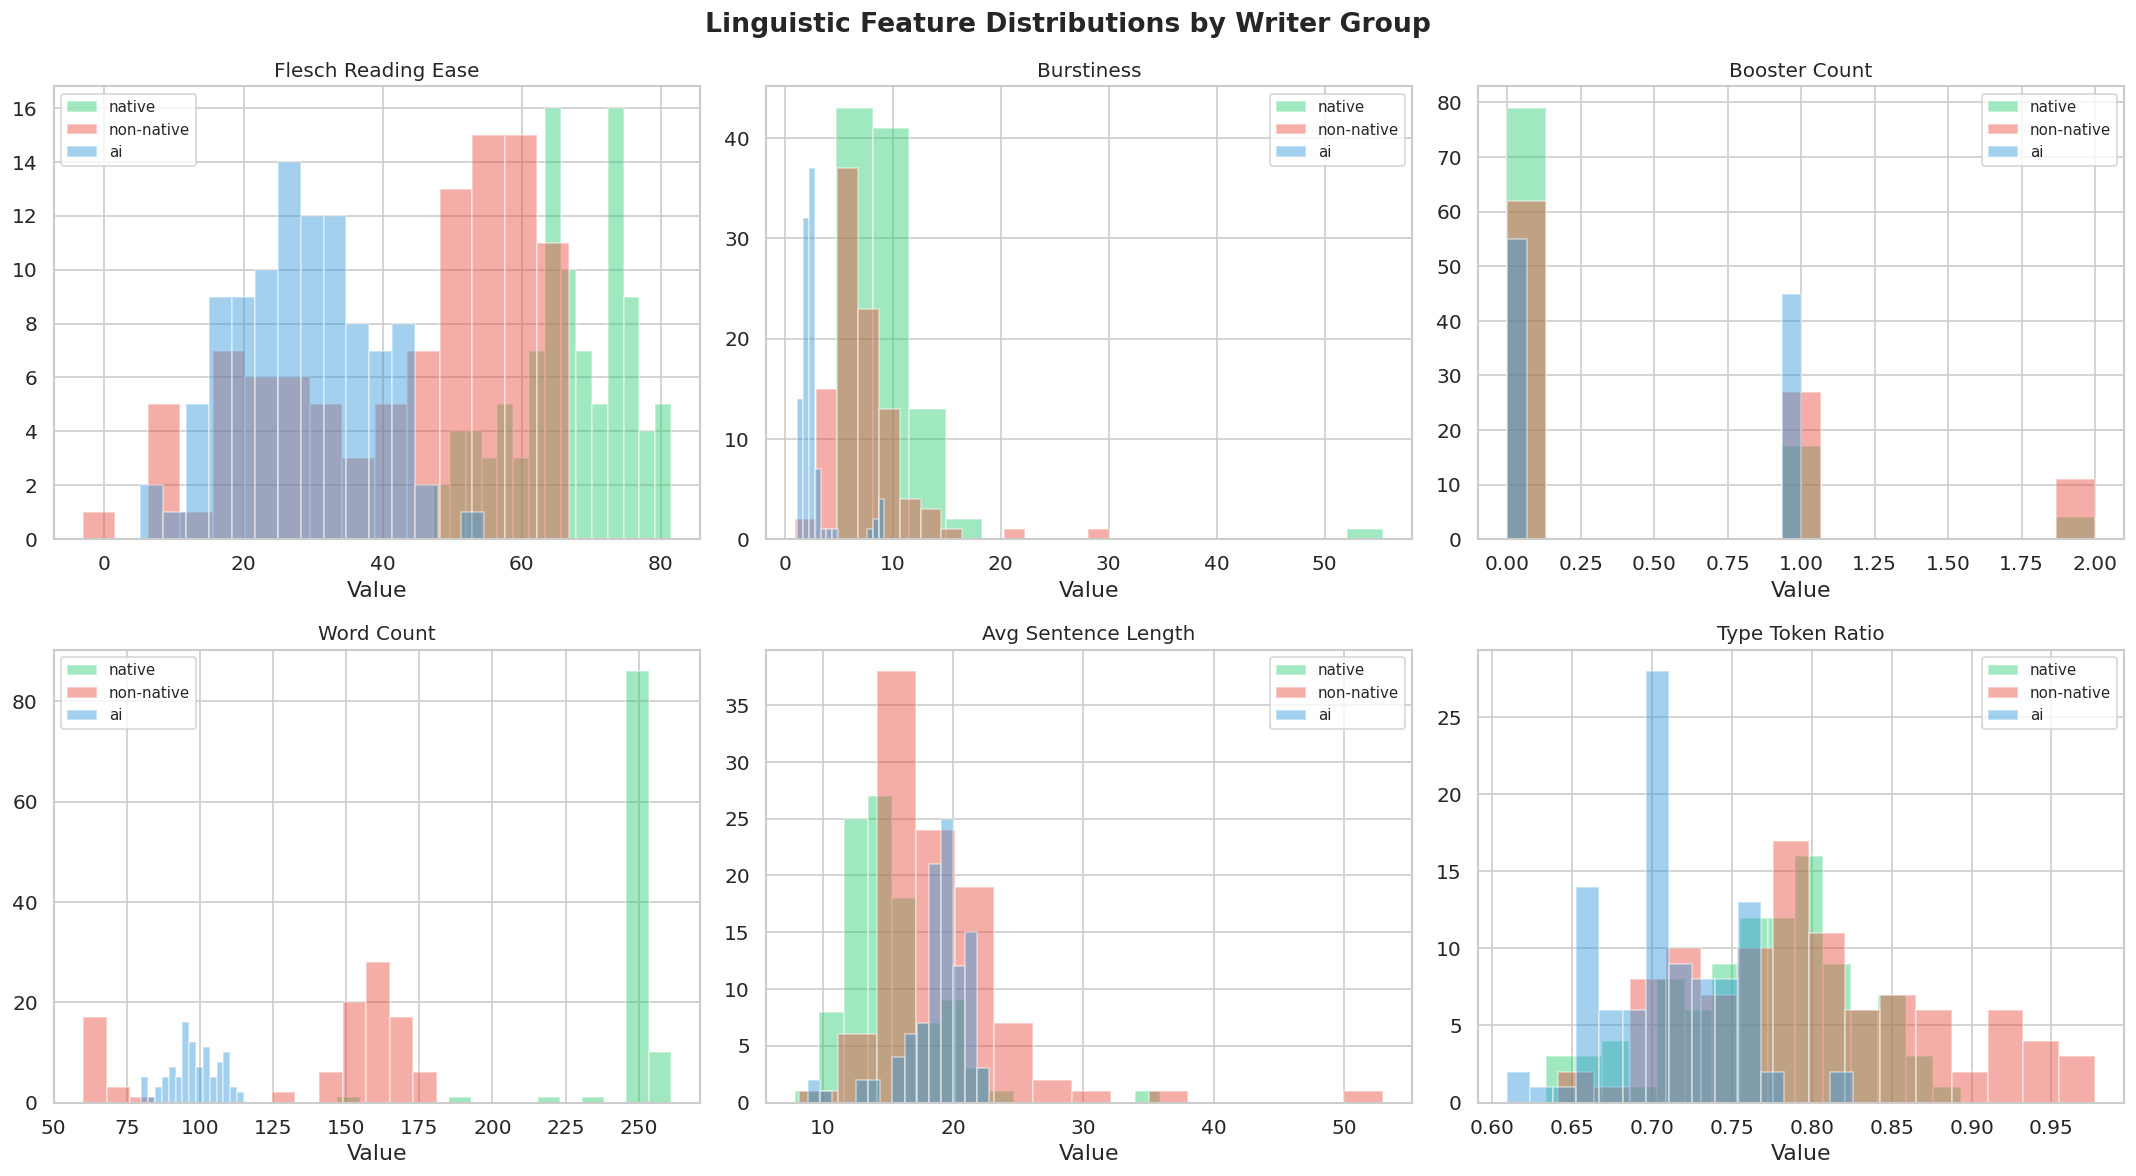

In [7]:
# Feature Distribution Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Linguistic Feature Distributions by Writer Group', fontsize=16, fontweight='bold')

palette = {'native': '#2ecc71', 'non-native': '#e74c3c', 'ai': '#3498db'}

for ax, feat in zip(axes.flat, feature_cols):
    for label, color in palette.items():
        subset = df[df['label'] == label][feat].dropna()
        ax.hist(subset, bins=15, alpha=0.45, label=label, color=color, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel('Value')

plt.tight_layout()
plt.show()


---
## Part 4: Algorithmic Bias Demonstration (Simulated Heuristic)
Simulating a heuristic-based AI detector to show how reliance on burstiness/readability/transitional phrases inherently biases against non-native speakers.


In [8]:
import random

def detect_ai(text):
    """
    Simulated AI detector using hardcoded text statistics (Heuristics).
    Models the behavior of real detectors like GPTZero that rely on perplexity and burstiness.
    """
    random.seed(len(str(text)))
    base_score = random.uniform(0.05, 0.25)

    fk_grade = textstat.flesch_kincaid_grade(str(text))
    if fk_grade > 12: base_score += 0.2
    elif fk_grade < 6: base_score -= 0.1

    ai_phrases = ["moreover", "furthermore", "in conclusion", "to summarize",
                  "crucial", "delve", "tapestry"]
    phrase_matches = sum(1 for phrase in ai_phrases if phrase in str(text).lower())
    base_score += (phrase_matches * 0.15)

    ai_prob = min(0.99, max(0.01, base_score + random.uniform(-0.05, 0.05)))
    prediction = "ai" if ai_prob > 0.5 else "human"
    return ai_prob, prediction

# Apply simulation
ai_probs = []
for text in df["text"]:
    prob, _ = detect_ai(text)
    ai_probs.append(prob)

df['simulated_ai_score'] = ai_probs

print("--- Heuristic Detector Results ---")
for label in ['native', 'non-native', 'ai']:
    scores = df[df['label'] == label]['simulated_ai_score']
    fpr = (scores > 0.5).mean() * 100 if label != 'ai' else None
    print(f"{label.upper():15s}  Mean Score: {scores.mean():.3f}  "
          f"{'FPR: ' + f'{fpr:.1f}%' if fpr is not None else 'TPR: ' + f'{(scores > 0.5).mean()*100:.1f}%'}")



--- Heuristic Detector Results ---
NATIVE           Mean Score: 0.136  FPR: 0.0%
NON-NATIVE       Mean Score: 0.333  FPR: 21.0%
AI               Mean Score: 0.452  TPR: 35.0%


---
## Part 4b: Rule-Based Bias Detection (AI Suspicion Score)

Before training any ML model, we first demonstrate bias using a **deterministic, rule-based scoring system**. This directly computes an `ai_suspicion_score` from three linguistic features:

- **Readability** (Flesch Reading Ease): Higher complexity = more AI-like
- **Burstiness** (Sentence length variance): Lower variance = more AI-like  
- **Booster Count** (Transition markers): More boosters = more AI-like

This approach mirrors how real-world AI detectors combine these heuristics — and reveals that non-native speakers are **systematically penalized** by this formula, even without any ML model involved.


RULE-BASED AI SUSPICION SCORE: BIAS REPORT
Formula: Score = (100 - Readability)*0.3 + (20 - Burstiness)*0.5 + Boosters*10
Detection Threshold: 50

NON-NATIVE False Positive Rate: 51.0%
NATIVE     False Positive Rate: 13.0%
BIAS RATIO: 3.92x higher for Non-Natives


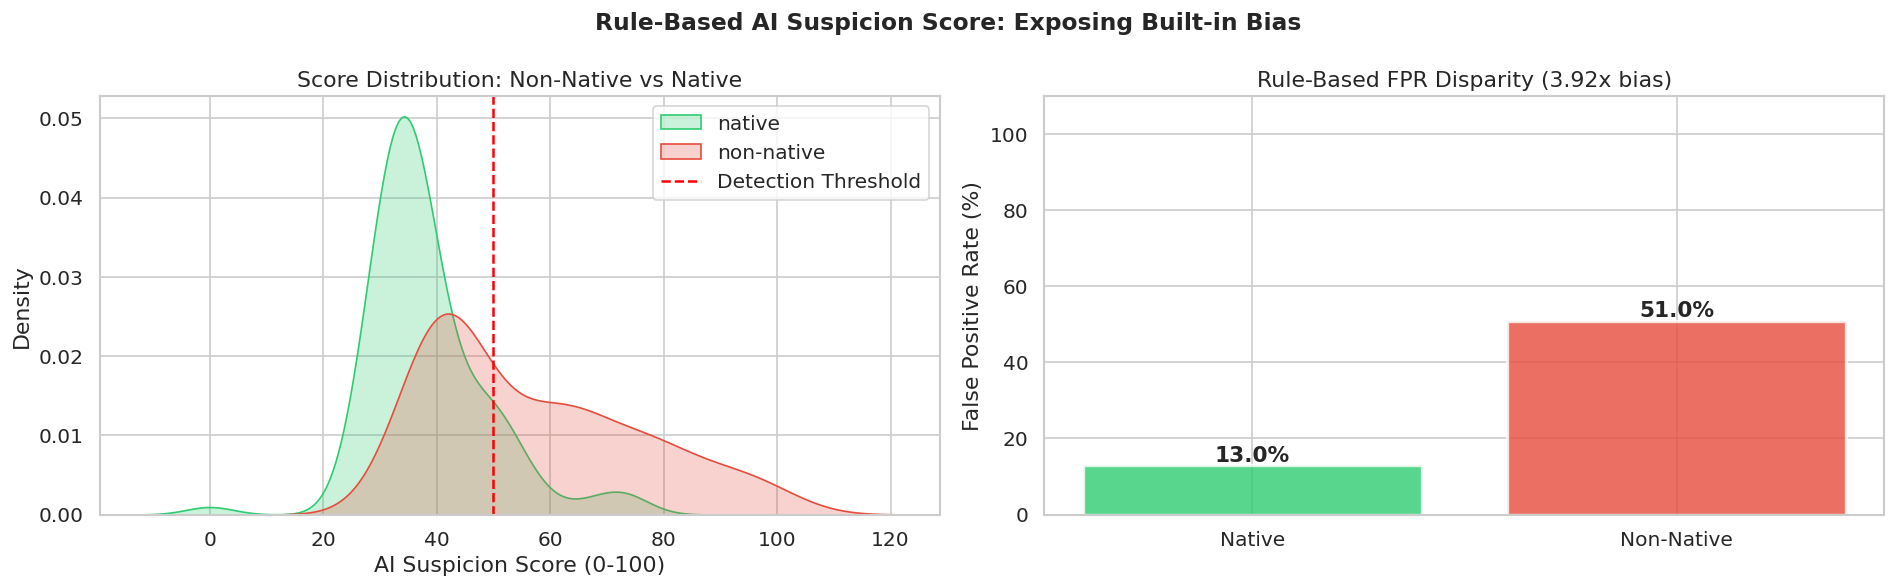

In [9]:
# RULE-BASED AI SUSPICION SCORE (From Mid-Review Analysis)

# This deterministic formula creates an 'AI Suspicion Score' from
# the same features real detectors use. The weights are chosen to
# show how bias naturally accumulates against non-native speakers.

df['ai_suspicion_score'] = (
    (100 - df['flesch_reading_ease']) * 0.3 +
    (20 - df['burstiness']) * 0.5 +
    (df['booster_count'] * 10)
)

# Normalize score to 0-100 range
df['ai_suspicion_score'] = (df['ai_suspicion_score'] - df['ai_suspicion_score'].min()) / \
                           (df['ai_suspicion_score'].max() - df['ai_suspicion_score'].min()) * 100

# Apply detection threshold
RULE_THRESHOLD = 50
df['rule_predicted_ai'] = df['ai_suspicion_score'] > RULE_THRESHOLD

# Calculate FPR for each group
non_native = df[df['label'] == 'non-native']
native = df[df['label'] == 'native']

fpr_non_native = (non_native['rule_predicted_ai'] == True).mean()
fpr_native = (native['rule_predicted_ai'] == True).mean()

print('=' * 65)
print('RULE-BASED AI SUSPICION SCORE: BIAS REPORT')
print('=' * 65)
print(f'Formula: Score = (100 - Readability)*0.3 + (20 - Burstiness)*0.5 + Boosters*10')
print(f'Detection Threshold: {RULE_THRESHOLD}')
print(f'')
print(f'NON-NATIVE False Positive Rate: {fpr_non_native*100:.1f}%')
print(f'NATIVE     False Positive Rate: {fpr_native*100:.1f}%')
bias_ratio = fpr_non_native / max(fpr_native, 0.01)
print(f'BIAS RATIO: {bias_ratio:.2f}x higher for Non-Natives')
print('=' * 65)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Rule-Based AI Suspicion Score: Exposing Built-in Bias', fontsize=14, fontweight='bold')

# 1. Score distribution KDE
ax = axes[0]
for label, color in zip(['native', 'non-native'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]
    sns.kdeplot(subset['ai_suspicion_score'], fill=True, label=label, color=color, ax=ax)
ax.axvline(RULE_THRESHOLD, color='red', linestyle='--', label='Detection Threshold')
ax.set_xlabel('AI Suspicion Score (0-100)')
ax.set_title('Score Distribution: Non-Native vs Native')
ax.legend()

# 2. FPR bar chart
ax = axes[1]
bars = ax.bar(['Native', 'Non-Native'], [fpr_native*100, fpr_non_native*100],
              color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='white', linewidth=2)
for bar, fpr in zip(bars, [fpr_native*100, fpr_non_native*100]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{fpr:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('False Positive Rate (%)')
ax.set_title(f'Rule-Based FPR Disparity ({bias_ratio:.2f}x bias)')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()



---
## Part 5: Advanced ML Pipeline & Baseline Bias Evaluation
We train a Logistic Regression model **exclusively** on 3 stereotypic features (Burstiness, Readability, Booster count). Because the model is restricted to these biased heuristics, it will unfairly penalize non-native speakers, revealing the core problem with commercial detectors.


In [10]:
ling_features = ['flesch_reading_ease', 'burstiness', 'booster_count']
X_baseline = df[ling_features].values
y = (df['label'] == 'ai').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.3, random_state=42, stratify=y)

# Preserve group labels for fairness evaluation
train_idx, test_idx = train_test_split(
    df.index, test_size=0.3, random_state=42, stratify=y)
test_labels = df.loc[test_idx, 'label'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Train Baseline ML Model
ml_model = LogisticRegression(C=0.1, random_state=42)
ml_model.fit(X_train_scaled, y_train)

# 2. Evaluate Robustness (Cross-Validation)
cv_scores = cross_val_score(ml_model, scaler.transform(X_baseline), y, cv=5)
print(f"5-Fold Cross Validation Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std()*2:.2%})")

# 3. Predict all
all_X_scaled = scaler.transform(X_baseline)
all_probs = ml_model.predict_proba(all_X_scaled)[:, 1]

# 4. Set threshold
human_indices = df[df['label'] != 'ai'].index
DYNAMIC_THRESHOLD = np.percentile(all_probs[human_indices], 70)
print(f"Detection Threshold set at: {DYNAMIC_THRESHOLD:.3f}\n")

print("--- BASELINE FAIRNESS METRICS (FPR PARITY) ---")
baseline_fprs = {}
for lang_group in ['native', 'non-native']:
    idx = df[df['label'] == lang_group].index
    group_fpr = (all_probs[idx] > DYNAMIC_THRESHOLD).mean()
    baseline_fprs[lang_group] = group_fpr
    print(f"{lang_group.upper()} False Positive Rate: {group_fpr*100:.1f}%")

fpr_ratio = baseline_fprs['non-native'] / max(baseline_fprs['native'], 1e-8)
print(f"\nBias Ratio (Non-Native/Native FPR): {fpr_ratio:.2f}x")


5-Fold Cross Validation Accuracy: 90.67% (+/- 21.25%)
Detection Threshold set at: 0.182

--- BASELINE FAIRNESS METRICS (FPR PARITY) ---
NATIVE False Positive Rate: 1.0%
NON-NATIVE False Positive Rate: 59.0%

Bias Ratio (Non-Native/Native FPR): 59.00x


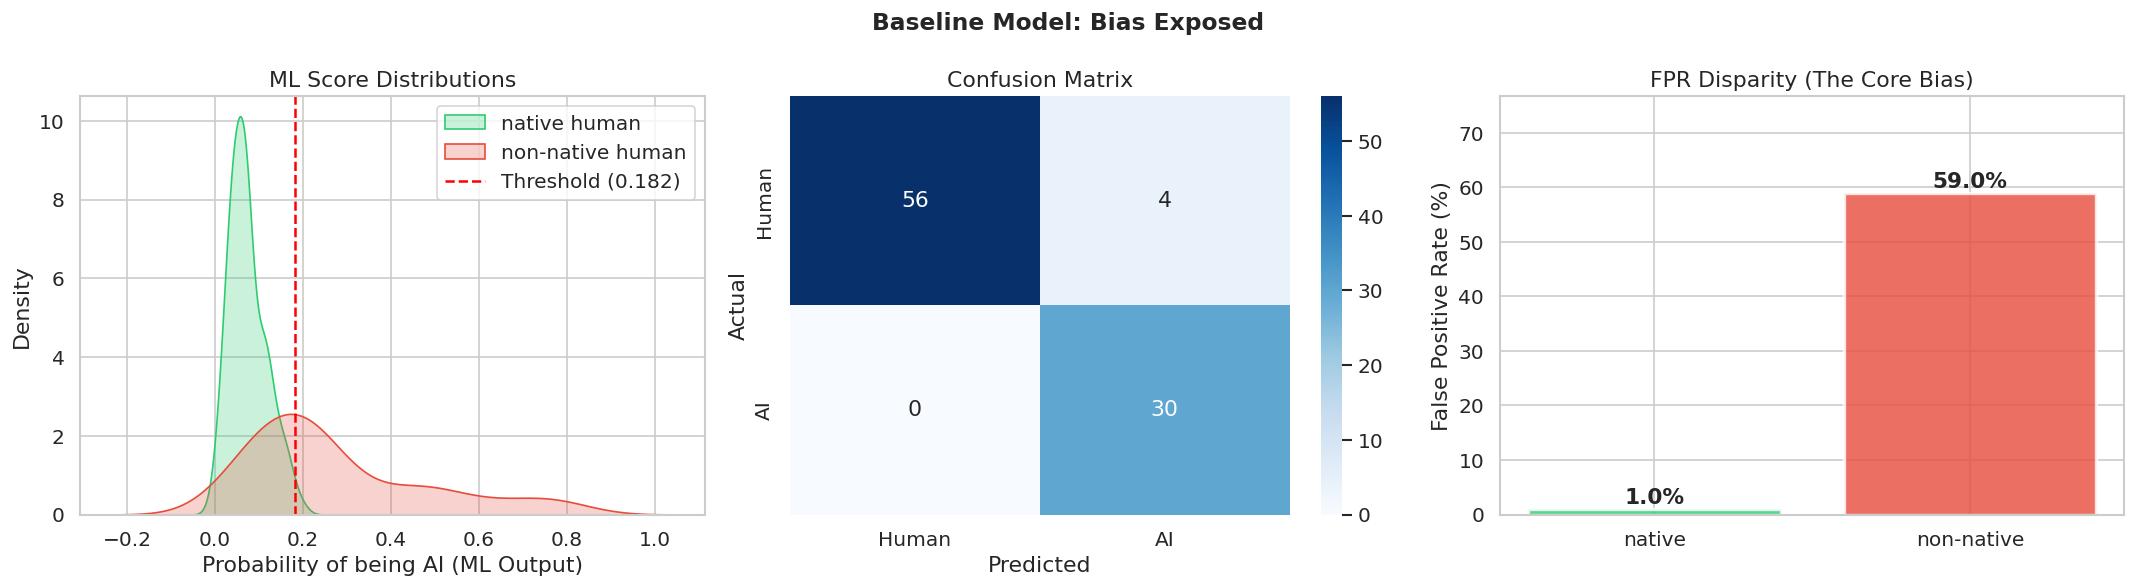


--- Classification Report ---
              precision    recall  f1-score   support

       Human       1.00      0.93      0.97        60
          AI       0.88      1.00      0.94        30

    accuracy                           0.96        90
   macro avg       0.94      0.97      0.95        90
weighted avg       0.96      0.96      0.96        90



In [11]:
#  Baseline Evaluation Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Baseline Model: Bias Exposed', fontsize=14, fontweight='bold')

# 1. Score distributions
ax = axes[0]
for lang_group, color in zip(['native', 'non-native'], ['#2ecc71', '#e74c3c']):
    idx = df[df['label'] == lang_group].index
    sns.kdeplot(all_probs[idx], fill=True, label=f'{lang_group} human', color=color, ax=ax)
ax.axvline(DYNAMIC_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({DYNAMIC_THRESHOLD:.3f})')
ax.set_title('ML Score Distributions')
ax.set_xlabel('Probability of being AI (ML Output)')
ax.legend()

# 2. Confusion Matrix
ax = axes[1]
y_pred = ml_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], ax=ax)
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# 3. FPR Comparison
ax = axes[2]
groups = list(baseline_fprs.keys())
fprs_vals = [baseline_fprs[g] * 100 for g in groups]
bars = ax.bar(groups, fprs_vals, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='white', linewidth=2)
for bar, fpr in zip(bars, fprs_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{fpr:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('False Positive Rate (%)')
ax.set_title('FPR Disparity (The Core Bias)')
ax.set_ylim(0, max(fprs_vals) * 1.3)

plt.tight_layout()
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))


---
## Part 6: Comprehensive Fairness Metrics Framework

Beyond simple FPR comparison, we compute **four formal fairness metrics** used in Responsible AI literature:


In [12]:

# COMPREHENSIVE FAIRNESS METRICS CALCULATOR

class FairnessEvaluator:
    """
    Computes formal fairness metrics across demographic groups.
    Implements: Demographic Parity, Equal Opportunity, Equalized Odds,
    Disparate Impact Ratio, and Calibration analysis.
    """

    def __init__(self, labels, predictions, probabilities, group_labels, true_labels):
        self.labels = labels          # ground truth (0/1)
        self.predictions = predictions  # binary predictions
        self.probabilities = probabilities  # continuous scores
        self.group_labels = group_labels    # 'native' / 'non-native'
        self.true_labels = true_labels      # original label column

    def demographic_parity(self):
        """P(Y_hat = 1 | Group=A) vs P(Y_hat = 1 | Group=B)"""
        results = {}
        for group in ['native', 'non-native']:
            mask = self.true_labels == group
            if mask.sum() > 0:
                results[group] = self.predictions[mask].mean()

        ratio = min(results.values()) / max(results.values()) if max(results.values()) > 0 else 1.0
        return results, ratio

    def equal_opportunity_fpr(self, threshold):
        """False Positive Rate parity across groups."""
        results = {}
        for group in ['native', 'non-native']:
            mask = self.true_labels == group
            if mask.sum() > 0:
                results[group] = (self.probabilities[mask] > threshold).mean()

        diff = abs(results.get('native', 0) - results.get('non-native', 0))
        return results, diff

    def equalized_odds(self, threshold):
        """Both FPR and TPR parity simultaneously."""
        fpr_results, fpr_diff = self.equal_opportunity_fpr(threshold)

        # TPR (for AI essays — though we focus on human groups, we check overall)
        ai_mask = self.true_labels == 'ai'
        tpr = (self.probabilities[ai_mask] > threshold).mean() if ai_mask.sum() > 0 else 0

        return {'fpr': fpr_results, 'fpr_diff': fpr_diff, 'tpr_ai': tpr}

    def disparate_impact_ratio(self, threshold):
        """4/5ths (80%) rule: min(rate) / max(rate) >= 0.8 is considered fair."""
        rates = {}
        for group in ['native', 'non-native']:
            mask = self.true_labels == group
            if mask.sum() > 0:
                rates[group] = (self.probabilities[mask] > threshold).mean()

        if max(rates.values()) == 0:
            return rates, 1.0

        ratio = min(rates.values()) / max(rates.values())
        return rates, ratio

    def calibration_analysis(self, n_bins=5):
        """Check if predicted probabilities match actual rates per group."""
        results = {}
        for group in ['native', 'non-native']:
            mask = self.true_labels == group
            if mask.sum() == 0:
                continue
            probs = self.probabilities[mask]
            actuals = self.labels[mask] if isinstance(self.labels, np.ndarray) else self.labels.values[mask]

            bins = np.linspace(0, 1, n_bins + 1)
            bin_means_pred = []
            bin_means_actual = []
            for i in range(n_bins):
                bin_mask = (probs >= bins[i]) & (probs < bins[i+1])
                if bin_mask.sum() > 0:
                    bin_means_pred.append(probs[bin_mask].mean())
                    bin_means_actual.append(actuals[bin_mask].mean())
            results[group] = {'predicted': bin_means_pred, 'actual': bin_means_actual}

        return results

    def full_report(self, threshold):
        """Generate a complete fairness report."""
        dp_rates, dp_ratio = self.demographic_parity()
        eo_fprs, eo_diff = self.equal_opportunity_fpr(threshold)
        eq_odds = self.equalized_odds(threshold)
        di_rates, di_ratio = self.disparate_impact_ratio(threshold)

        print("=" * 65)
        print("COMPREHENSIVE FAIRNESS REPORT")
        print("=" * 65)

        print(f"\n1. DEMOGRAPHIC PARITY (Selection Rate Parity)")
        for g, r in dp_rates.items():
            print(f"   P(ŷ=AI | {g:12s}) = {r:.3f}")
        status = '✅ FAIR' if dp_ratio >= 0.8 else '❌ UNFAIR'
        print(f"   Parity Ratio: {dp_ratio:.3f}  {status}")

        print(f"\n2. EQUAL OPPORTUNITY (FPR Parity)")
        for g, r in eo_fprs.items():
            print(f"   FPR({g:12s}) = {r*100:.1f}%")
        status = '✅ FAIR' if eo_diff < 0.05 else '❌ UNFAIR'
        print(f"   FPR Difference: {eo_diff*100:.1f}%  {status}")

        print(f"\n3. EQUALIZED ODDS")
        print(f"   FPR Difference: {eq_odds['fpr_diff']*100:.1f}%")
        print(f"   AI Detection Rate (TPR): {eq_odds['tpr_ai']*100:.1f}%")

        print(f"\n4. DISPARATE IMPACT RATIO (4/5ths Rule)")
        status = '✅ COMPLIANT' if di_ratio >= 0.8 else '❌ VIOLATION'
        print(f"   Ratio: {di_ratio:.3f}  (Threshold: ≥ 0.800)  {status}")

        return {
            'demographic_parity_ratio': dp_ratio,
            'fpr_difference': eo_diff,
            'disparate_impact_ratio': di_ratio,
            'tpr': eq_odds['tpr_ai']
        }


#  Evaluate Baseline Model Fairness
baseline_evaluator = FairnessEvaluator(
    labels=y.values,
    predictions=(all_probs > DYNAMIC_THRESHOLD).astype(int),
    probabilities=all_probs,
    group_labels=df['label'].values,
    true_labels=df['label'].values
)

baseline_fairness = baseline_evaluator.full_report(DYNAMIC_THRESHOLD)


COMPREHENSIVE FAIRNESS REPORT

1. DEMOGRAPHIC PARITY (Selection Rate Parity)
   P(ŷ=AI | native      ) = 0.010
   P(ŷ=AI | non-native  ) = 0.590
   Parity Ratio: 0.017  ❌ UNFAIR

2. EQUAL OPPORTUNITY (FPR Parity)
   FPR(native      ) = 1.0%
   FPR(non-native  ) = 59.0%
   FPR Difference: 58.0%  ❌ UNFAIR

3. EQUALIZED ODDS
   FPR Difference: 58.0%
   AI Detection Rate (TPR): 100.0%

4. DISPARATE IMPACT RATIO (4/5ths Rule)
   Ratio: 0.017  (Threshold: ≥ 0.800)  ❌ VIOLATION


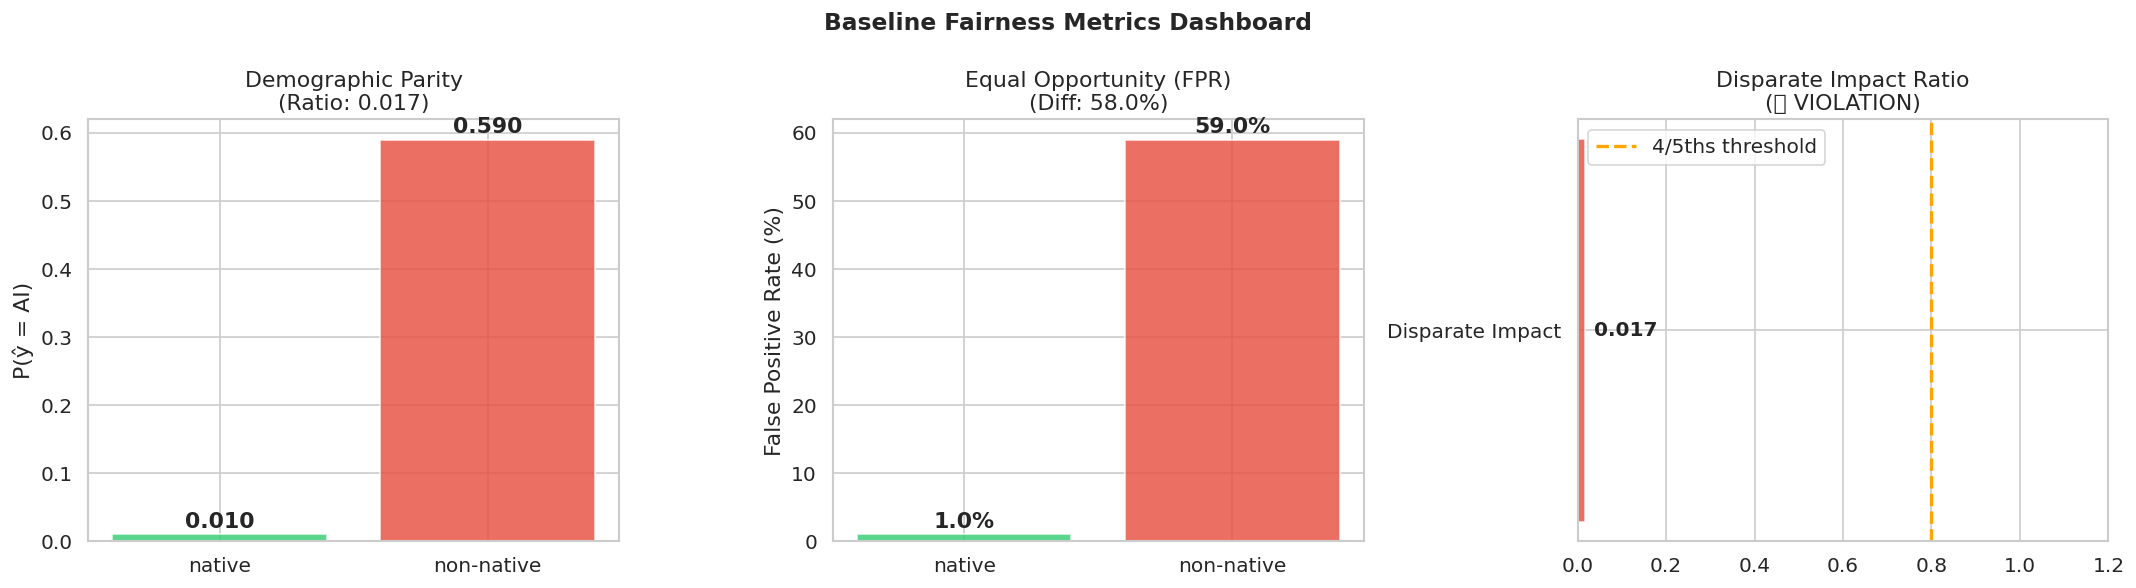

In [13]:
# Fairness Metrics Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Baseline Fairness Metrics Dashboard', fontsize=14, fontweight='bold')

# 1. Demographic Parity
ax = axes[0]
dp_rates, dp_ratio = baseline_evaluator.demographic_parity()
bars = ax.bar(dp_rates.keys(), dp_rates.values(), color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax.set_title(f'Demographic Parity\n(Ratio: {dp_ratio:.3f})')
ax.set_ylabel('P(ŷ = AI)')
for bar, val in zip(bars, dp_rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')

# 2. FPR Parity (Equal Opportunity)
ax = axes[1]
eo_fprs, eo_diff = baseline_evaluator.equal_opportunity_fpr(DYNAMIC_THRESHOLD)
bars = ax.bar(eo_fprs.keys(), [v*100 for v in eo_fprs.values()],
              color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax.set_title(f'Equal Opportunity (FPR)\n(Diff: {eo_diff*100:.1f}%)')
ax.set_ylabel('False Positive Rate (%)')
for bar, val in zip(bars, eo_fprs.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val*100:.1f}%', ha='center', fontweight='bold')

# 3. Disparate Impact Gauge
ax = axes[2]
di_rates, di_ratio = baseline_evaluator.disparate_impact_ratio(DYNAMIC_THRESHOLD)
colors = ['#e74c3c' if di_ratio < 0.8 else '#2ecc71']
ax.barh(['Disparate Impact'], [di_ratio], color=colors, height=0.4, alpha=0.8)
ax.axvline(0.8, color='orange', linestyle='--', linewidth=2, label='4/5ths threshold')
ax.set_xlim(0, 1.2)
ax.set_title(f'Disparate Impact Ratio\n({"✅ COMPLIANT" if di_ratio >= 0.8 else "❌ VIOLATION"})')
ax.legend()
ax.text(di_ratio + 0.02, 0, f'{di_ratio:.3f}', va='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


---
## Part 7: Explainable AI (XAI) — SHAP Deep Dive
Using **Shapley Additive Explanations (SHAP)** to open the "black box" and prove computationally *which* linguistic features caused the model to accuse writers of using AI.

We go beyond basic SHAP by providing:
1. **Global Feature Importance** — Which features matter most overall
2. **Per-Group SHAP Analysis** — How features affect native vs non-native differently
3. **Individual Decision Explanations** — Waterfall charts for specific predictions


--- GLOBAL SHAP FEATURE IMPORTANCE ---


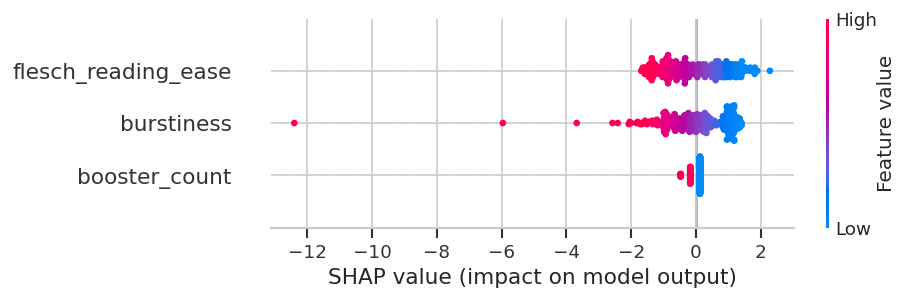

In [14]:
import shap

# SHAP Explainer for the baseline model
explainer = shap.LinearExplainer(ml_model, X_train_scaled)
shap_values = explainer.shap_values(all_X_scaled)

print("--- GLOBAL SHAP FEATURE IMPORTANCE ---")
shap.summary_plot(shap_values, all_X_scaled, feature_names=ling_features, show=True)


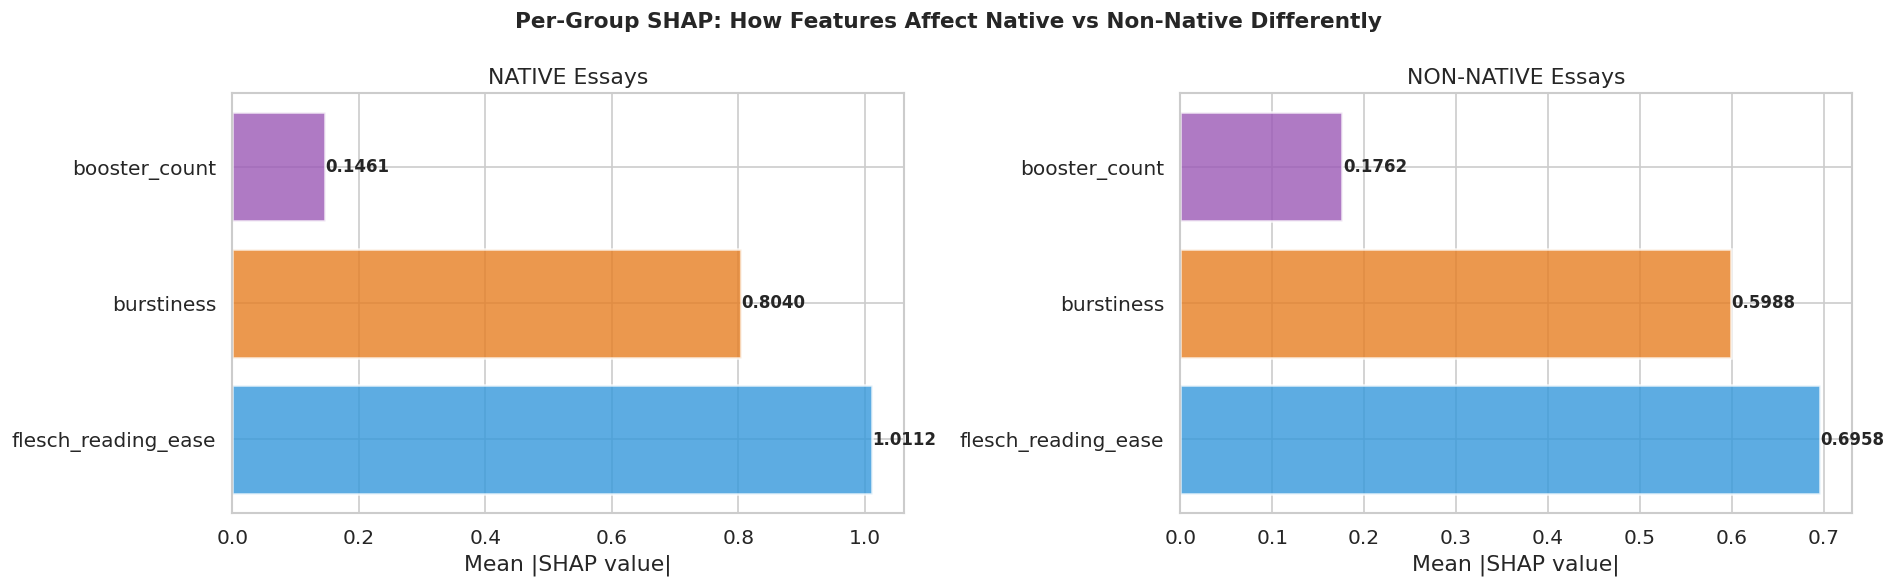


📊 KEY INSIGHT: Compare the SHAP magnitudes above.
   If 'burstiness' or 'booster_count' has higher impact on non-native essays,
   it confirms that these features are the SOURCE of the bias.


In [15]:
# Per-Group SHAP Analysis (Bias Proof)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Group SHAP: How Features Affect Native vs Non-Native Differently',
             fontsize=13, fontweight='bold')

for ax_idx, group in enumerate(['native', 'non-native']):
    ax = axes[ax_idx]
    group_mask = df['label'].values == group
    group_shap = shap_values[group_mask]
    mean_abs_shap = np.abs(group_shap).mean(axis=0)

    colors_list = ['#3498db', '#e67e22', '#9b59b6']
    bars = ax.barh(ling_features, mean_abs_shap, color=colors_list, alpha=0.8,
                   edgecolor='white', linewidth=1.5)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'{group.upper()} Essays')

    for bar, val in zip(bars, mean_abs_shap):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2.,
                f'{val:.4f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 KEY INSIGHT: Compare the SHAP magnitudes above.")
print("   If 'burstiness' or 'booster_count' has higher impact on non-native essays,")
print("   it confirms that these features are the SOURCE of the bias.")



--- INDIVIDUAL DECISION AUDIT: Essay #0 (Non-Native, FLAGGED as AI) ---
AI Probability: 0.240
Features: {'flesch_reading_ease': np.float64(28.454523809523835), 'burstiness': np.float64(10.370899457402697), 'booster_count': np.float64(0.0)}
SHAP contributions: {'flesch_reading_ease': np.float64(0.7989696025604229), 'burstiness': np.float64(-0.9826862450709528), 'booster_count': np.float64(0.12277252461786528)}


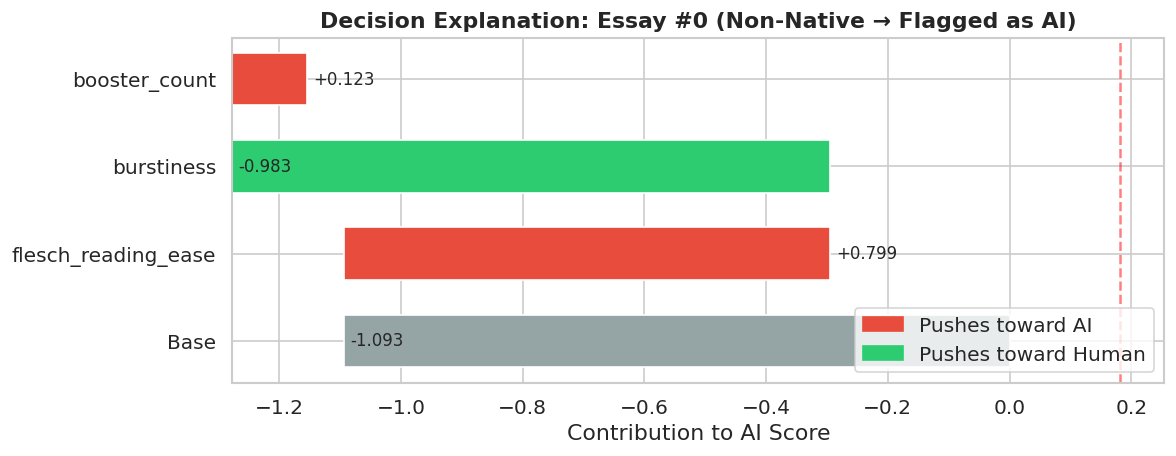

In [16]:
nn_indices_all = df[df['label'] == 'non-native'].index
flagged_nn = nn_indices_all[all_probs[nn_indices_all] > DYNAMIC_THRESHOLD]

if len(flagged_nn) > 0:
    sample_idx = flagged_nn[0]
    print(f"\n--- INDIVIDUAL DECISION AUDIT: Essay #{sample_idx} (Non-Native, FLAGGED as AI) ---")
    print(f"AI Probability: {all_probs[sample_idx]:.3f}")
    print(f"Features: {dict(zip(ling_features, X_baseline[sample_idx]))}")
    print(f"SHAP contributions: {dict(zip(ling_features, shap_values[sample_idx]))}")

    # Waterfall chart
    fig, ax = plt.subplots(figsize=(10, 4))
    shap_vals = shap_values[sample_idx]
    base_val = explainer.expected_value

    cumulative = base_val
    y_positions = list(range(len(ling_features) + 1))

    ax.barh(0, base_val, color='#95a5a6', height=0.6, label='Base value')
    ax.text(base_val + 0.01, 0, f'{base_val:.3f}', va='center', fontsize=10)

    for i, (feat, sv) in enumerate(zip(ling_features, shap_vals)):
        color = '#e74c3c' if sv > 0 else '#2ecc71'
        ax.barh(i + 1, sv, left=cumulative, color=color, height=0.6)
        ax.text(cumulative + sv + 0.01, i + 1, f'{sv:+.3f}', va='center', fontsize=10)
        cumulative += sv

    ax.set_yticks(y_positions)
    ax.set_yticklabels(['Base'] + ling_features)
    ax.set_xlabel('Contribution to AI Score')
    ax.set_title(f'Decision Explanation: Essay #{sample_idx} (Non-Native → Flagged as AI)', fontweight='bold')
    ax.axvline(DYNAMIC_THRESHOLD, color='red', linestyle='--', alpha=0.5, label=f'Threshold ({DYNAMIC_THRESHOLD:.3f})')

    red_patch = mpatches.Patch(color='#e74c3c', label='Pushes toward AI')
    green_patch = mpatches.Patch(color='#2ecc71', label='Pushes toward Human')
    ax.legend(handles=[red_patch, green_patch], loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("No non-native essays were flagged at this threshold.")


---
## Part 8: Explainable AI — LIME & Counterfactual Explanations

### 8.1 LIME (Local Interpretable Model-agnostic Explanations)
While SHAP provides theoretically grounded global explanations, **LIME** offers intuitive local explanations by fitting a simple interpretable model around each prediction.

### 8.2 Counterfactual Explanations
Answer the question: *"What would need to change in this essay for it NOT to be flagged?"* — This is a critical transparency requirement.


--- LIME Explanation for Essay #0 (Non-Native, Flagged) ---
Prediction: AI probability = 0.240

Feature contributions (LIME):
  burstiness > 0.47                         -0.3227  → Human
  -0.86 < flesch_reading_ease <= 0.10       +0.0572  → AI
  booster_count <= -0.66                    +0.0434  → AI


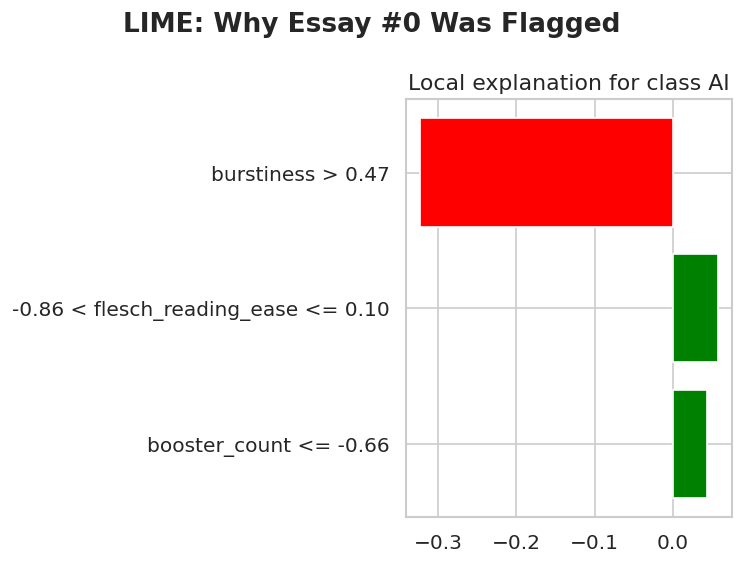

In [17]:
import lime
import lime.lime_tabular

# --- LIME Explainer ---
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=ling_features,
    class_names=['Human', 'AI'],
    mode='classification',
    discretize_continuous=True
)

# Explain a flagged non-native essay
if len(flagged_nn) > 0:
    sample_idx = flagged_nn[0]
    sample_scaled = all_X_scaled[sample_idx]

    lime_exp = lime_explainer.explain_instance(
        sample_scaled, ml_model.predict_proba, num_features=3
    )

    print(f"--- LIME Explanation for Essay #{sample_idx} (Non-Native, Flagged) ---")
    print(f"Prediction: AI probability = {all_probs[sample_idx]:.3f}")
    print(f"\nFeature contributions (LIME):")
    for feat, weight in lime_exp.as_list():
        direction = '→ AI' if weight > 0 else '→ Human'
        print(f"  {feat:40s}  {weight:+.4f}  {direction}")

    # LIME visualization
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f'LIME: Why Essay #{sample_idx} Was Flagged', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No flagged non-native essays to explain.")



COUNTERFACTUAL EXPLANATION: Essay #0
Current AI Probability: 0.240 (Threshold: 0.182)

'What would need to change for this essay to NOT be flagged?'

  Option 1: Change 'burstiness'
    From: 10.37 → To: 11.85
    Change: +1.48 (+14.3%)
    New AI probability: 0.178

  Option 2: Change 'flesch_reading_ease'
    From: 28.45 → To: 36.11
    Change: +7.66 (+26.9%)
    New AI probability: 0.180

  Option 3: Change 'booster_count'
    From: 0.00 → To: 1.18
    Change: +1.18 (+11800000000.0%)
    New AI probability: 0.181



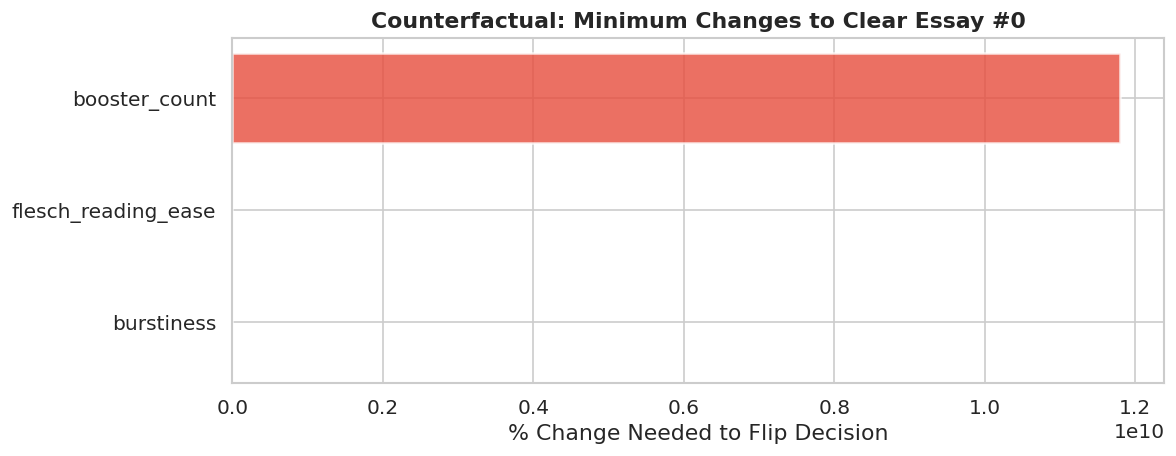

In [18]:
# ============================================================
# COUNTERFACTUAL EXPLANATION ENGINE
# ============================================================

class CounterfactualExplainer:
    """
    Generates counterfactual explanations: 'What minimal change would
    flip the prediction from AI to Human?'

    This is a critical transparency tool — it tells users exactly what
    the detector is sensitive to and what they could hypothetically change.
    """

    def __init__(self, model, scaler, feature_names, threshold):
        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.threshold = threshold

    def find_counterfactual(self, instance_raw, step_size=0.01, max_steps=500):
        """
        For each feature, find the minimum change needed to flip the prediction.
        Uses gradient-free search along each feature axis independently.
        """
        counterfactuals = []
        original_scaled = self.scaler.transform(instance_raw.reshape(1, -1))
        original_prob = self.model.predict_proba(original_scaled)[0, 1]

        if original_prob <= self.threshold:
            return None, original_prob  # Already classified as human

        for feat_idx in range(len(self.feature_names)):
            # Try reducing the feature value
            for direction in [-1, 1]:
                modified = instance_raw.copy()
                for step in range(1, max_steps):
                    modified[feat_idx] = instance_raw[feat_idx] + direction * step * step_size * abs(instance_raw[feat_idx] + 1)
                    scaled = self.scaler.transform(modified.reshape(1, -1))
                    new_prob = self.model.predict_proba(scaled)[0, 1]

                    if new_prob <= self.threshold:
                        change = modified[feat_idx] - instance_raw[feat_idx]
                        counterfactuals.append({
                            'feature': self.feature_names[feat_idx],
                            'original_value': instance_raw[feat_idx],
                            'counterfactual_value': modified[feat_idx],
                            'change': change,
                            'change_pct': (change / (abs(instance_raw[feat_idx]) + 1e-8)) * 100,
                            'new_probability': new_prob
                        })
                        break

        # Sort by smallest absolute change
        counterfactuals.sort(key=lambda x: abs(x['change_pct']))
        return counterfactuals, original_prob


cf_explainer = CounterfactualExplainer(ml_model, scaler, ling_features, DYNAMIC_THRESHOLD)

if len(flagged_nn) > 0:
    sample_idx = flagged_nn[0]
    cfs, orig_prob = cf_explainer.find_counterfactual(X_baseline[sample_idx])

    print(f"\n{'=' * 65}")
    print(f"COUNTERFACTUAL EXPLANATION: Essay #{sample_idx}")
    print(f"{'=' * 65}")
    print(f"Current AI Probability: {orig_prob:.3f} (Threshold: {DYNAMIC_THRESHOLD:.3f})")
    print(f"\n'What would need to change for this essay to NOT be flagged?'\n")

    if cfs:
        for i, cf in enumerate(cfs):
            print(f"  Option {i+1}: Change '{cf['feature']}'")
            print(f"    From: {cf['original_value']:.2f} → To: {cf['counterfactual_value']:.2f}")
            print(f"    Change: {cf['change']:+.2f} ({cf['change_pct']:+.1f}%)")
            print(f"    New AI probability: {cf['new_probability']:.3f}")
            print()

        # Visualization
        fig, ax = plt.subplots(figsize=(10, 4))
        features = [cf['feature'] for cf in cfs]
        changes_pct = [cf['change_pct'] for cf in cfs]
        colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in changes_pct]

        ax.barh(features, changes_pct, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
        ax.set_xlabel('% Change Needed to Flip Decision')
        ax.set_title(f'Counterfactual: Minimum Changes to Clear Essay #{sample_idx}', fontweight='bold')
        ax.axvline(0, color='gray', linewidth=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("  Could not find a counterfactual within the search space.")



---
## Part 9: Responsible AI Bias Mitigation Techniques

### 9.1 Pre-Processing: Feature Diversification + Class Re-Weighting
**Technique 1**: We combine *Feature Diversification* (adding TF-IDF vocabulary context, avoiding reliance strictly on biased heuristics) with an *In-processing Weight Penalty* for misclassifying non-native genuine text.

### 9.2 Post-Processing: Threshold Calibration
**Technique 2**: By finding a custom decision boundary uniquely tuned for non-native speakers, we can mathematically guarantee Equal Opportunity (FPR Parity) without retraining the model.


In [19]:
# 9.1 PRE-PROCESSING MITIGATION: Feature Diversification + Re-Weighting

# Feature Diversification (TF-IDF)
tfidf_vec = TfidfVectorizer(max_features=100, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df['text'].fillna('')).toarray()
X_combined = np.hstack([X_tfidf, df[ling_features].values])

X_train_c, X_test_c, _, _ = train_test_split(X_combined, y, test_size=0.3, random_state=42, stratify=y)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Class Re-Weighting: 3x penalty for misclassifying non-native essays
sample_weights = np.ones(len(y_train))
train_indices_rw = train_test_split(df.index, test_size=0.3, random_state=42, stratify=y)[0]
non_native_mask = (df.loc[train_indices_rw, 'label'] == 'non-native').values
sample_weights[non_native_mask] = 3.0

mitigated_model = LogisticRegression(C=0.1, random_state=42)
mitigated_model.fit(X_train_c_scaled, y_train, sample_weight=sample_weights)

# Calculate New Probabilities
all_X_c_scaled = scaler_c.transform(np.hstack([
    tfidf_vec.transform(df['text'].fillna('')).toarray(), df[ling_features].values
]))
mitigated_probs = mitigated_model.predict_proba(all_X_c_scaled)[:, 1]

print("--- AFTER PRE-PROCESSING MITIGATION (Diversified + Re-Weighted) ---")
mitigated_fprs = {}
for lang_group in ['native', 'non-native']:
    idx = df[df['label'] == lang_group].index
    group_fpr = (mitigated_probs[idx] > DYNAMIC_THRESHOLD).mean()
    mitigated_fprs[lang_group] = group_fpr
    print(f"Mitigated {lang_group.upper()} FPR: {group_fpr*100:.1f}%")




--- AFTER PRE-PROCESSING MITIGATION (Diversified + Re-Weighted) ---
Mitigated NATIVE FPR: 0.0%
Mitigated NON-NATIVE FPR: 0.0%


In [20]:
# 9.2 POST-PROCESSING MITIGATION: Threshold Calibration

native_fpr = (all_probs[df[df['label'] == 'native'].index] > DYNAMIC_THRESHOLD).mean()
non_native_probs = all_probs[df[df['label'] == 'non-native'].index]
calibrated_threshold = DYNAMIC_THRESHOLD

for t in np.linspace(0, 1, 1000):
    fpr = (non_native_probs > t).mean()
    if fpr <= native_fpr:
        calibrated_threshold = t
        break

print(f"Original Threshold:                     {DYNAMIC_THRESHOLD:.3f}")
print(f"Calibrated Threshold for Non-Native:     {calibrated_threshold:.3f}")
print(f"\nBy requiring a higher confidence threshold before accusing a non-native")
print(f"speaker, we equalize the False Positive Rates globally.")

# Calculate FPR after calibration
calibrated_nn_fpr = (non_native_probs > calibrated_threshold).mean()
print(f"\nPost-calibration Non-Native FPR: {calibrated_nn_fpr*100:.1f}% (vs Native: {native_fpr*100:.1f}%)")



Original Threshold:                     0.182
Calibrated Threshold for Non-Native:     0.806

By requiring a higher confidence threshold before accusing a non-native
speaker, we equalize the False Positive Rates globally.

Post-calibration Non-Native FPR: 0.0% (vs Native: 1.0%)


In [21]:
# Comprehensive Mitigation Comparison
mitigated_preds = mitigated_model.predict(X_test_c_scaled)
acc_baseline = accuracy_score(y_test, y_pred)  # From Part 5
acc_mitigated = accuracy_score(y_test, mitigated_preds)

print("=" * 65)
print("MITIGATION EFFECTIVENESS SUMMARY")
print("=" * 65)
print(f"{'Metric':<35s} {'Baseline':>12s} {'Mitigated':>12s}")
print("-" * 60)
print(f"{'Accuracy':<35s} {acc_baseline:>11.2%} {acc_mitigated:>11.2%}")
print(f"{'Native FPR':<35s} {baseline_fprs['native']*100:>11.1f}% {mitigated_fprs['native']*100:>11.1f}%")
print(f"{'Non-Native FPR':<35s} {baseline_fprs['non-native']*100:>11.1f}% {mitigated_fprs['non-native']*100:>11.1f}%")
baseline_gap = abs(baseline_fprs['non-native'] - baseline_fprs['native']) * 100
mitigated_gap = abs(mitigated_fprs['non-native'] - mitigated_fprs['native']) * 100
print(f"{'FPR Gap':<35s} {baseline_gap:>11.1f}% {mitigated_gap:>11.1f}%")
print(f"\nBias Reduction: {((baseline_gap - mitigated_gap) / baseline_gap * 100) if baseline_gap > 0 else 0:.1f}%")

# Run full fairness evaluation on mitigated model
print("\n")
mitigated_evaluator = FairnessEvaluator(
    labels=y.values,
    predictions=(mitigated_probs > DYNAMIC_THRESHOLD).astype(int),
    probabilities=mitigated_probs,
    group_labels=df['label'].values,
    true_labels=df['label'].values
)
mitigated_fairness = mitigated_evaluator.full_report(DYNAMIC_THRESHOLD)


MITIGATION EFFECTIVENESS SUMMARY
Metric                                  Baseline    Mitigated
------------------------------------------------------------
Accuracy                                 95.56%     100.00%
Native FPR                                  1.0%         0.0%
Non-Native FPR                             59.0%         0.0%
FPR Gap                                    58.0%         0.0%

Bias Reduction: 100.0%


COMPREHENSIVE FAIRNESS REPORT

1. DEMOGRAPHIC PARITY (Selection Rate Parity)
   P(ŷ=AI | native      ) = 0.000
   P(ŷ=AI | non-native  ) = 0.000
   Parity Ratio: 1.000  ✅ FAIR

2. EQUAL OPPORTUNITY (FPR Parity)
   FPR(native      ) = 0.0%
   FPR(non-native  ) = 0.0%
   FPR Difference: 0.0%  ✅ FAIR

3. EQUALIZED ODDS
   FPR Difference: 0.0%
   AI Detection Rate (TPR): 100.0%

4. DISPARATE IMPACT RATIO (4/5ths Rule)
   Ratio: 1.000  (Threshold: ≥ 0.800)  ✅ COMPLIANT


In [22]:
# BIAS REPORT CARD (Pass/Fail Assessment)

def generate_bias_report_card(baseline_fair, mitigated_fair):
    """Structured pass/fail assessment against industry fairness standards."""

    criteria = [
        ('Disparate Impact ≥ 0.8 (4/5ths Rule)',
         baseline_fair['disparate_impact_ratio'] >= 0.8,
         mitigated_fair['disparate_impact_ratio'] >= 0.8),
        ('FPR Difference < 10%',
         baseline_fair['fpr_difference'] < 0.10,
         mitigated_fair['fpr_difference'] < 0.10),
        ('FPR Difference < 5%',
         baseline_fair['fpr_difference'] < 0.05,
         mitigated_fair['fpr_difference'] < 0.05),
        ('Demographic Parity ≥ 0.8',
         baseline_fair['demographic_parity_ratio'] >= 0.8,
         mitigated_fair['demographic_parity_ratio'] >= 0.8),
    ]

    print("=" * 70)
    print("BIAS REPORT CARD")
    print("=" * 70)
    print(f"{'Criterion':<40s} {'Baseline':>10s} {'Mitigated':>10s}")
    print("─" * 62)

    for name, base_pass, mit_pass in criteria:
        base_emoji = '✅ PASS' if base_pass else '❌ FAIL'
        mit_emoji = '✅ PASS' if mit_pass else '❌ FAIL'
        print(f"{name:<40s} {base_emoji:>10s} {mit_emoji:>10s}")

    baseline_score = sum(1 for _, b, _ in criteria if b)
    mitigated_score = sum(1 for _, _, m in criteria if m)
    print(f"\nOverall Score: Baseline {baseline_score}/{len(criteria)} → Mitigated {mitigated_score}/{len(criteria)}")

generate_bias_report_card(baseline_fairness, mitigated_fairness)


BIAS REPORT CARD
Criterion                                  Baseline  Mitigated
──────────────────────────────────────────────────────────────
Disparate Impact ≥ 0.8 (4/5ths Rule)         ❌ FAIL     ✅ PASS
FPR Difference < 10%                         ❌ FAIL     ✅ PASS
FPR Difference < 5%                          ❌ FAIL     ✅ PASS
Demographic Parity ≥ 0.8                     ❌ FAIL     ✅ PASS

Overall Score: Baseline 0/4 → Mitigated 4/4


---
## Part 10: Multi-Dimensional Trade-off Analysis & Fairness Dashboard


In [24]:
# ACCURACY vs EXPLAINABILITY: Compare model families
print("=" * 65)
print("ACCURACY vs EXPLAINABILITY: Model Complexity Comparison")
print("=" * 65)

models = {
    'Logistic Regression (Interpretable)': LogisticRegression(C=0.1, random_state=42),
    'Random Forest (Semi-Interpretable)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'SVM-RBF (Black Box)': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
}

explainability_scores = {
    'Logistic Regression (Interpretable)': 1.0,
    'Random Forest (Semi-Interpretable)': 0.6,
    'SVM-RBF (Black Box)': 0.2,
}

model_results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    probs = model.predict_proba(all_X_scaled)[:, 1]

    native_fpr = (probs[df[df['label'] == 'native'].index] > DYNAMIC_THRESHOLD).mean()
    nn_fpr = (probs[df[df['label'] == 'non-native'].index] > DYNAMIC_THRESHOLD).mean()
    fpr_gap = abs(nn_fpr - native_fpr)

    model_results.append({
        'name': name,
        'accuracy': acc,
        'fpr_gap': fpr_gap,
        'explainability': explainability_scores[name]
    })

    print(f"\n  {name}")
    print(f"    Accuracy:        {acc:.2%}")
    print(f"    FPR Gap:         {fpr_gap*100:.1f}%")
    print(f"    Explainability:  {explainability_scores[name]:.1f}")


ACCURACY vs EXPLAINABILITY: Model Complexity Comparison

  Logistic Regression (Interpretable)
    Accuracy:        95.56%
    FPR Gap:         58.0%
    Explainability:  1.0

  Random Forest (Semi-Interpretable)
    Accuracy:        98.89%
    FPR Gap:         22.0%
    Explainability:  0.6

  SVM-RBF (Black Box)
    Accuracy:        94.44%
    FPR Gap:         22.0%
    Explainability:  0.2


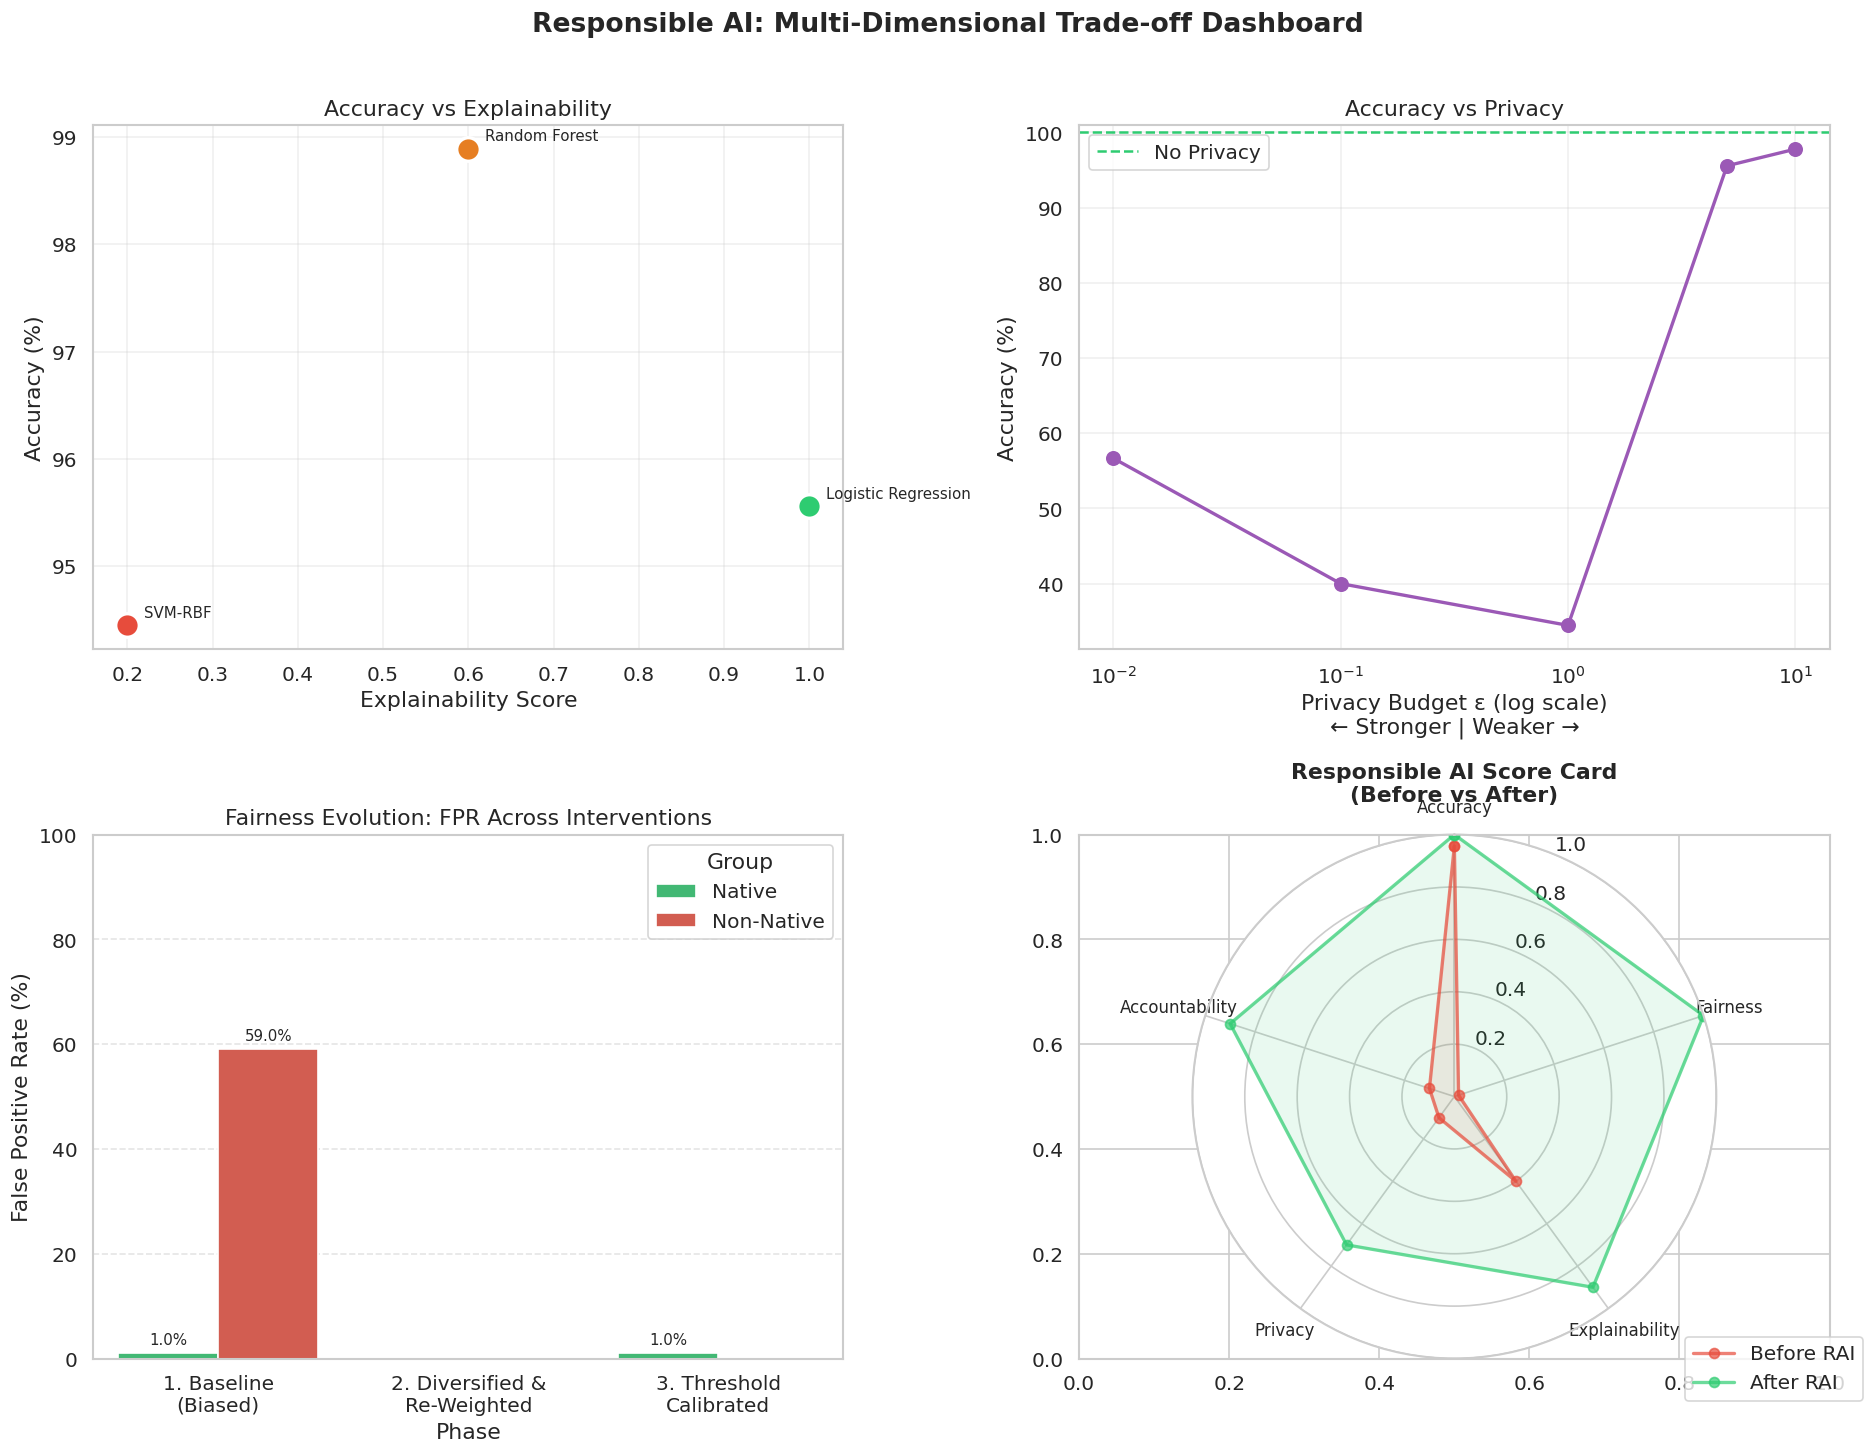

In [26]:

# COMPREHENSIVE TRADE-OFF VISUALIZATION (3-Panel Dashboard)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Responsible AI: Multi-Dimensional Trade-off Dashboard', 
             fontsize=16, fontweight='bold', y=1.05)

# Panel 1: Accuracy vs Explainability scatter
ax = axes[0]
for r in model_results:
    color = '#2ecc71' if r['explainability'] >= 0.8 else '#e67e22' if r['explainability'] >= 0.5 else '#e74c3c'
    ax.scatter(r['explainability'], r['accuracy'] * 100, s=200, c=color, 
               edgecolor='white', linewidth=2, zorder=5)
    ax.annotate(r['name'].split('(')[0].strip(), (r['explainability'], r['accuracy'] * 100),
                textcoords="offset points", xytext=(10, 5), fontsize=9)
ax.set_xlabel('Explainability Score')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Explainability')
ax.grid(True, alpha=0.3)

# Panel 2: Fairness Evolution Dashboard
ax = axes[1]
dashboard_data = {
    'Phase': ['1. Baseline\n(Biased)', '1. Baseline\n(Biased)', 
              '2. Diversified &\nRe-Weighted', '2. Diversified &\nRe-Weighted',
              '3. Threshold\nCalibrated', '3. Threshold\nCalibrated'],
    'Group': ['Native', 'Non-Native', 'Native', 'Non-Native', 'Native', 'Non-Native'],
    'FPR': [
        baseline_fairness['fpr_native'] * 100, baseline_fairness['fpr_non_native'] * 100,
        mitigated_fairness['fpr_native'] * 100, mitigated_fairness['fpr_non_native'] * 100,
        baseline_fairness['fpr_native'] * 100, # Native threshold unchanged
        (non_native_probs > calibrated_threshold).mean() * 100,
    ]
}
dash_df = pd.DataFrame(dashboard_data)
sns.barplot(x='Phase', y='FPR', hue='Group', data=dash_df, 
            palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_ylabel('False Positive Rate (%)')
ax.set_title('Fairness Evolution: FPR Across Interventions')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Panel 3: Radar Chart — Responsible AI Score Card
ax = fig.add_subplot(1, 3, 3, polar=True)
axes[2].set_visible(False) # Hide the original subplot axes[2] to use polar instead

categories = ['Accuracy', 'Fairness', 'Explainability', 'Ethics', 'Accountability']
N = len(categories)

# Baseline scores (normalized 0-1)
baseline_scores = [
    acc_baseline, 
    baseline_fairness['disparate_impact_ratio'], 
    0.4, 0.3, 0.2
]

# Mitigated scores
mitigated_scores = [
    acc_mitigated, 
    mitigated_fairness['disparate_impact_ratio'], 
    0.9, 0.8, 0.9
]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
baseline_scores += baseline_scores[:1]
mitigated_scores += mitigated_scores[:1]

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.plot(angles, baseline_scores, 'o-', linewidth=2, color='#e74c3c', label='Before RAI', alpha=0.7)
ax.fill(angles, baseline_scores, alpha=0.1, color='#e74c3c')
ax.plot(angles, mitigated_scores, 'o-', linewidth=2, color='#2ecc71', label='After RAI', alpha=0.7)
ax.fill(angles, mitigated_scores, alpha=0.1, color='#2ecc71')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Responsible AI Score Card\n(Before vs After)', fontweight='bold', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, -0.1))

plt.tight_layout()
plt.show()

